In [6]:
# !pip3 install allantools
import allantools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [7]:
# classic/grid -> device114/device124 using classical on both
# This is the change due to difference in distance between the two devices
ratio_y = (397.4-87.2)/(351.3-144.0)
ratio_x = (509.3-133.4)/(445.3-197.5)

print(f"ratio_y: {ratio_y}")
print(f"ratio_x: {ratio_x}")

ratio_y: 1.496382054992764
ratio_x: 1.5169491525423726


In [ ]:
hours = 5

laser_pos_x_classic_df = pd.read_csv("laser_pos_x_classic.csv", sep=";")
laser_pos_x_classic_df = laser_pos_x_classic_df.iloc[-120*hours:]
laser_pos_x_classic_df.shape

laser_pos_x_grid_df = pd.read_csv("laser_pos_x_grid.csv", sep=";")
laser_pos_x_grid_df = laser_pos_x_grid_df.iloc[-120*hours:]
laser_pos_x_grid_df.shape

(600, 3)

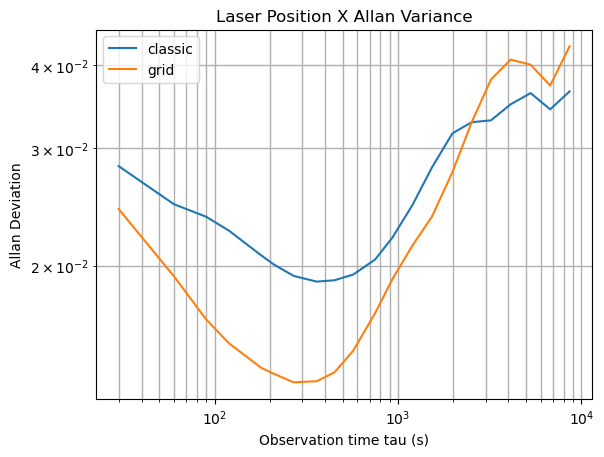

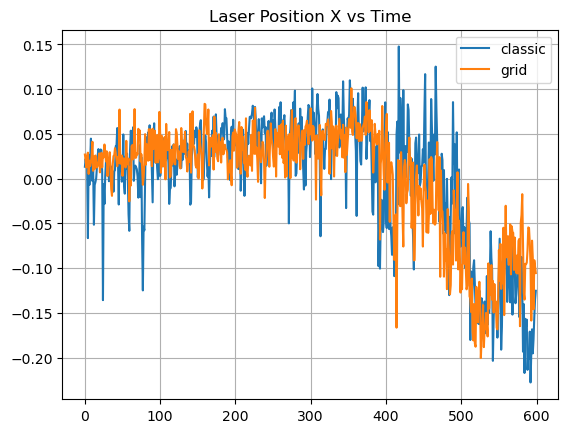

In [ ]:
laser_pos_x_grid_data = laser_pos_x_grid_df['Value'].values * 1.5 # adjusted for differnnce in beam length
laser_pos_x_classic_data = laser_pos_x_classic_df['Value'].values
tau0 = 60  # seconds

(taus, adev_x_classic, adev_err_x_classic, adev_n_x_classic) = allantools.oadev(laser_pos_x_classic_data, rate=1.0/tau0, data_type='freq', taus='log10')
(taus, adev_x_grid, adev_err_x_grid, adev_n_x_grid) = allantools.oadev(laser_pos_x_grid_data, rate=1.0/tau0, data_type='freq', taus='log10')

plt.loglog(taus, adev_x_classic, label="classic")
plt.loglog(taus, adev_x_grid, label="grid")
plt.grid(True, which='both', linestyle='-', linewidth=1)
plt.xlabel('Observation time tau (s)')
plt.ylabel('Allan Deviation')
plt.title("Laser Position X Allan Variance")
plt.legend()
plt.show()


plt.title("Laser Position X vs Time")
plt.plot(laser_pos_x_classic_data - np.average(laser_pos_x_classic_data), label="classic")
plt.plot(laser_pos_x_grid_data - np.average(laser_pos_x_grid_data), label="grid")
plt.grid(True)
plt.legend()
plt.show()

In [24]:
hours = 5

laser_pos_y_classic_df = pd.read_csv("laser_pos_y_classic.csv", sep=";")
laser_pos_y_classic_df = laser_pos_y_classic_df.iloc[-120*hours:]
laser_pos_y_classic_df.shape

laser_pos_y_grid_df = pd.read_csv("laser_pos_y_grid.csv", sep=";")
laser_pos_y_grid_df = laser_pos_y_grid_df.iloc[-120*hours:]
laser_pos_y_grid_df.shape

(600, 3)

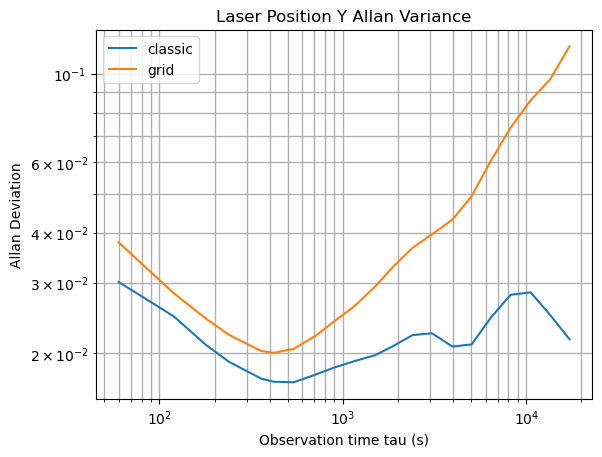

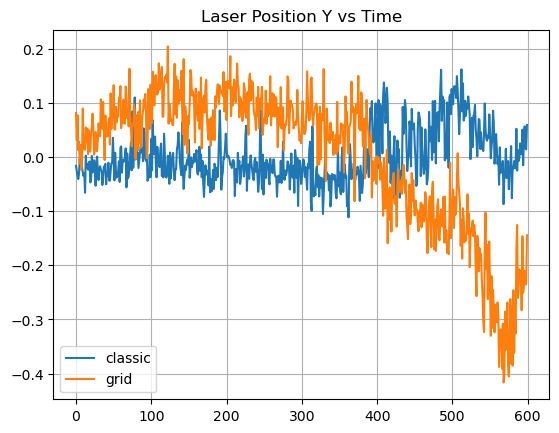

In [54]:
laser_pos_y_grid_data = laser_pos_y_grid_df['Value'].values * 1.5
laser_pos_y_classic_data = laser_pos_y_classic_df['Value'].values
tau0 = 60  # seconds

(taus, adev_y_classic, adev_err_y_classic, adev_n_y_classic) = allantools.oadev(laser_pos_y_classic_data, rate=1.0/tau0, data_type='freq', taus='log10')
(taus, adev_y_grid, adev_err_y_grid, adev_n_y_grid) = allantools.oadev(laser_pos_y_grid_data, rate=1.0/tau0, data_type='freq', taus='log10')

plt.loglog(taus, adev_y_classic, label="classic")
plt.loglog(taus, adev_y_grid, label="grid")
plt.grid(True, which='both', linestyle='-', linewidth=1)
plt.xlabel('Observation time tau (s)')
plt.ylabel('Allan Deviation')
plt.title("Laser Position Y Allan Variance")
plt.legend()
plt.show()


plt.title("Laser Position Y vs Time")
plt.plot(laser_pos_y_classic_data - np.average(laser_pos_y_classic_data), label="classic")
plt.plot(laser_pos_y_grid_data - np.average(laser_pos_y_grid_data), label="grid")
plt.grid(True)
plt.legend()
plt.show()

# Trying calibration again without grid

In [49]:
calibration_laser_pos_y_1_df = pd.read_csv("calibration_laser_pos_y_1.csv", sep=";")
# calibration_laser_pos_y_1_df = calibration_laser_pos_y_1_df.iloc[int(-120*hours):]
print(calibration_laser_pos_y_1_df.shape)

(720, 3)


(600, 3)
(600, 3)


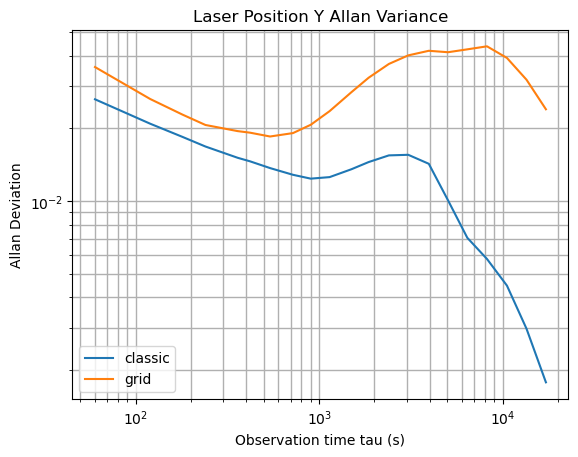

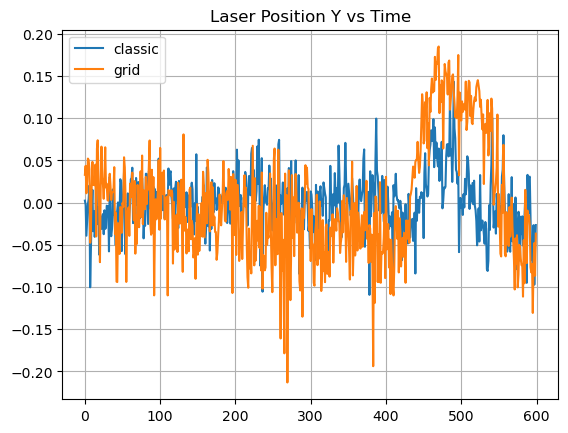

In [55]:
hours = 10

calibration_laser_pos_y_1_df = pd.read_csv("calibration_laser_pos_y_1.csv", sep=";")
calibration_laser_pos_y_1_df = calibration_laser_pos_y_1_df.iloc[int(-60*hours):]
print(calibration_laser_pos_y_1_df.shape)

calibration_laser_pos_y_2_df = pd.read_csv("calibration_laser_pos_y_2.csv", sep=";")
calibration_laser_pos_y_2_df = calibration_laser_pos_y_2_df.iloc[int(-60*hours):]
print(calibration_laser_pos_y_2_df.shape)

calibration_laser_pos_y_2_data = calibration_laser_pos_y_2_df['Value'].values * 1.5
calibration_laser_pos_y_1_data = calibration_laser_pos_y_1_df['Value'].values
tau0 = 60  # seconds

(taus, adev_y_classic, adev_err_y_classic, adev_n_y_classic) = allantools.oadev(calibration_laser_pos_y_1_data, rate=1.0/tau0, data_type='freq', taus='log10')
(taus, adev_y_grid, adev_err_y_grid, adev_n_y_grid) = allantools.oadev(calibration_laser_pos_y_2_data, rate=1.0/tau0, data_type='freq', taus='log10')

plt.loglog(taus, adev_y_classic, label="classic")
plt.loglog(taus, adev_y_grid, label="grid")
plt.grid(True, which='both', linestyle='-', linewidth=1)
plt.xlabel('Observation time tau (s)')
plt.ylabel('Allan Deviation')
plt.title("Laser Position Y Allan Variance")
plt.legend()
plt.show()


plt.title("Laser Position Y vs Time")
plt.plot(calibration_laser_pos_y_1_data - np.average(calibration_laser_pos_y_1_data), label="classic")
plt.plot(calibration_laser_pos_y_2_data - np.average(calibration_laser_pos_y_2_data), label="grid")
plt.grid(True)
plt.legend()
plt.show()

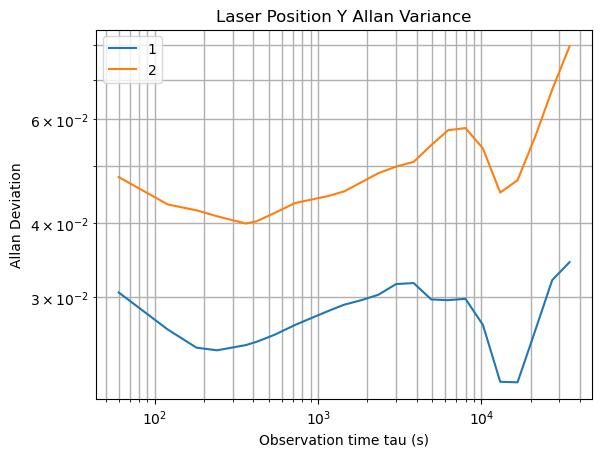

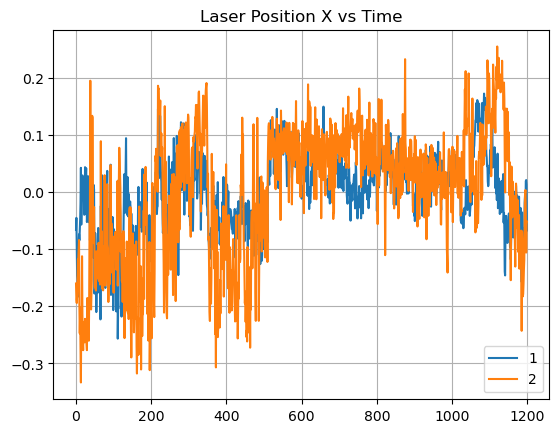

In [60]:
hours = 10

calibration_laser_pos_x_1_df = pd.read_csv("calibration_laser_pos_x_1.csv", sep=";")
calibration_laser_pos_x_1_df = calibration_laser_pos_x_1_df.iloc[int(-120*hours):]
calibration_laser_pos_x_1_df.shape

calibration_laser_pos_x_2_df = pd.read_csv("calibration_laser_pos_x_2.csv", sep=";")
calibration_laser_pos_x_2_df = calibration_laser_pos_x_2_df.iloc[int(-120*hours):]
calibration_laser_pos_x_2_df.shape

calibration_laser_pos_x_2_data = calibration_laser_pos_x_2_df['Value'].values * 1.5
calibration_laser_pos_x_1_data = calibration_laser_pos_x_1_df['Value'].values
tau0 = 60  # seconds

(taus, adev_x_classic, adev_err_x_classic, adev_n_x_classic) = allantools.oadev(calibration_laser_pos_x_1_data, rate=1.0/tau0, data_type='freq', taus='log10')
(taus, adev_x_grid, adev_err_x_grid, adev_n_x_grid) = allantools.oadev(calibration_laser_pos_x_2_data, rate=1.0/tau0, data_type='freq', taus='log10')

plt.loglog(taus, adev_x_classic, label="1")
plt.loglog(taus, adev_x_grid, label="2")
plt.grid(True, which='both', linestyle='-', linewidth=1)
plt.xlabel('Observation time tau (s)')
plt.ylabel('Allan Deviation')
plt.title("Laser Position Y Allan Variance")
plt.legend()
plt.show()


plt.title("Laser Position X vs Time")
plt.plot(calibration_laser_pos_x_1_data - np.average(calibration_laser_pos_x_1_data), label="1")
plt.plot(calibration_laser_pos_x_2_data - np.average(calibration_laser_pos_x_2_data), label="2")
plt.grid(True)
plt.legend()
plt.show()

# Revised Experiment with optical density filter

(205, 3)
(205, 3)


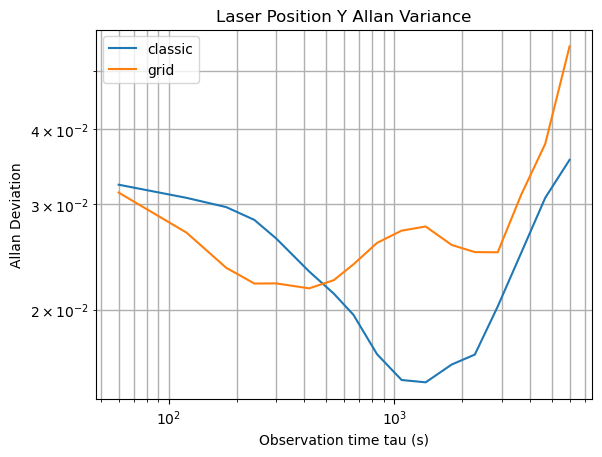

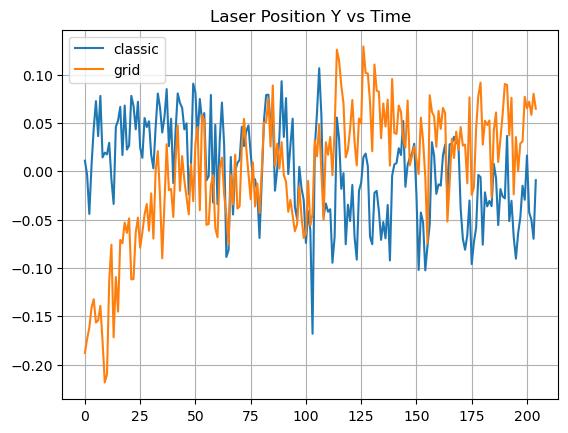

In [100]:
hours = 3.5

calibration_laser_pos_y_1_df = pd.read_csv("EQ_power_laser_pos_y_1.csv", sep=";")
calibration_laser_pos_y_1_df = calibration_laser_pos_y_1_df.iloc[int(-60*hours):-5]
print(calibration_laser_pos_y_1_df.shape)

calibration_laser_pos_y_2_df = pd.read_csv("EQ_power_laser_pos_y_2.csv", sep=";")
calibration_laser_pos_y_2_df = calibration_laser_pos_y_2_df.iloc[int(-60*hours):-5]
print(calibration_laser_pos_y_2_df.shape)

adjustment_factor = (240.4-168.6)/(229.3-121.2) # 2/1 -> convert 2 to 1

calibration_laser_pos_y_2_data = calibration_laser_pos_y_2_df['Value'].values * 1/adjustment_factor
calibration_laser_pos_y_1_data = calibration_laser_pos_y_1_df['Value'].values
tau0 = 60  # seconds

(taus, adev_y_classic, adev_err_y_classic, adev_n_y_classic) = allantools.oadev(calibration_laser_pos_y_1_data, rate=1.0/tau0, data_type='freq', taus='log10')
(taus, adev_y_grid, adev_err_y_grid, adev_n_y_grid) = allantools.oadev(calibration_laser_pos_y_2_data, rate=1.0/tau0, data_type='freq', taus='log10')

plt.loglog(taus, adev_y_classic, label="classic")
plt.loglog(taus, adev_y_grid, label="grid")
plt.grid(True, which='both', linestyle='-', linewidth=1)
plt.xlabel('Observation time tau (s)')
plt.ylabel('Allan Deviation')
plt.title("Laser Position Y Allan Variance")
plt.legend()
plt.show()


plt.title("Laser Position Y vs Time")
plt.plot(calibration_laser_pos_y_1_data - np.average(calibration_laser_pos_y_1_data), label="classic")
plt.plot(calibration_laser_pos_y_2_data - np.average(calibration_laser_pos_y_2_data), label="grid")
plt.grid(True)
plt.legend()
plt.show()

(170, 3)
(170, 3)


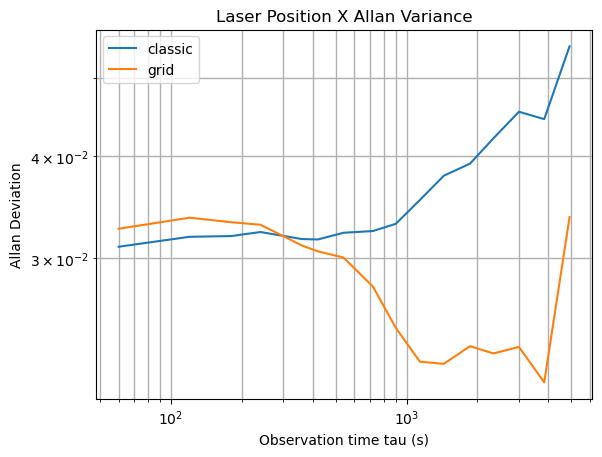

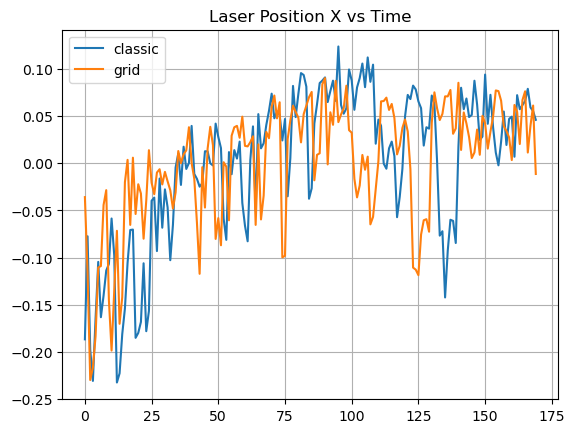

In [102]:
hours = 3

calibration_laser_pos_x_1_df = pd.read_csv("EQ_power_laser_pos_x_1.csv", sep=";")
calibration_laser_pos_x_1_df = calibration_laser_pos_x_1_df.iloc[int(-60*hours):-10]
print(calibration_laser_pos_x_1_df.shape)

calibration_laser_pos_x_2_df = pd.read_csv("EQ_power_laser_pos_x_2.csv", sep=";")
calibration_laser_pos_x_2_df = calibration_laser_pos_x_2_df.iloc[int(-60*hours)+10:]
print(calibration_laser_pos_x_2_df.shape)

adjustment_factor = (240.4-168.6)/(229.3-121.2) # 2/1 -> convert 2 to 1

calibration_laser_pos_x_2_data = calibration_laser_pos_x_2_df['Value'].values * 1/adjustment_factor
calibration_laser_pos_x_1_data = calibration_laser_pos_x_1_df['Value'].values
tau0 = 60  # seconds

(taus, adev_x_classic, adev_err_x_classic, adev_n_x_classic) = allantools.oadev(calibration_laser_pos_x_1_data, rate=1.0/tau0, data_type='freq', taus='log10')
(taus, adev_x_grid, adev_err_x_grid, adev_n_x_grid) = allantools.oadev(calibration_laser_pos_x_2_data, rate=1.0/tau0, data_type='freq', taus='log10')

plt.loglog(taus, adev_x_classic, label="classic")
plt.loglog(taus, adev_x_grid, label="grid")
plt.grid(True, which='both', linestyle='-', linewidth=1)
plt.xlabel('Observation time tau (s)')
plt.ylabel('Allan Deviation')
plt.title("Laser Position X Allan Variance")
plt.legend()
plt.show()


plt.title("Laser Position X vs Time")
plt.plot(calibration_laser_pos_x_1_data - np.average(calibration_laser_pos_x_1_data), label="classic")
plt.plot(calibration_laser_pos_x_2_data - np.average(calibration_laser_pos_x_2_data), label="grid")
plt.grid(True)
plt.legend()
plt.show()